1️⃣ Chargement des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [2]:
df = pd.read_csv('Clean_Dataset.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
df.shape

(300153, 12)

In [4]:
df.dtypes

Unnamed: 0            int64
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object

In [5]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


## 2️⃣ Analyse technique des variables


# Identifier les variables : discrète et continue

In [9]:
data = pd.read_csv('dcs.csv')
data
                 

,Colonne,Description,Nature Technique
0,airline,Nom de la compagnie aérienne.,Discrete (Nominal)
1,flight,Code d'identification du vol.,Categorical (ID)
2,source_city,Ville de départ du vol.,Discrete (Nominal)
3,departure_time,Tranche horaire du décollage.,Discrete (Nominal)
4,stops,Nombre d'escales effectuées.,Discrete (Ordinal)
5,arrival_time,Tranche horaire de l'arrivée.,Discrete ( Nominal)
6,destination_city,Ville d'arrivée du vol.,Discrete (Nominal)
7,class,Type de cabine (siège).,Discrete (Ordinal)
8,duration,Durée totale du vol (heures).,Continuous (Numerical)
9,days_left,Jours restants avant le vol.,Discrete (Numerical)


# Vérifier les types de données

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


In [11]:
df.dtypes

Unnamed: 0            int64
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object

In [16]:
discrete_vars = ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city']
continuous_vars = ['duration', 'price']

print("Discrete Variables:", discrete_vars)
print("Continuous Variables:", continuous_vars)


Discrete Variables: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city']
Continuous Variables: ['duration', 'price']


# 3️⃣ Analyse univariée

# Variables catégorielles 

# discrete :

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64


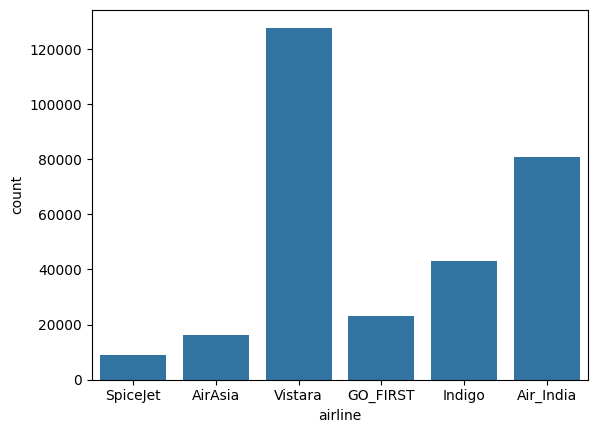

flight
UK-706     3235
UK-772     2741
UK-720     2650
UK-836     2542
UK-822     2468
           ... 
6E-6474       1
G8-405        1
6E-543        1
SG-1058       1
6E-3211       1
Name: count, Length: 1561, dtype: int64


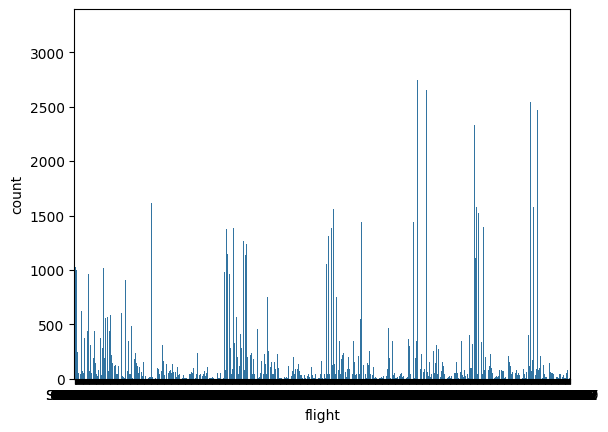

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64


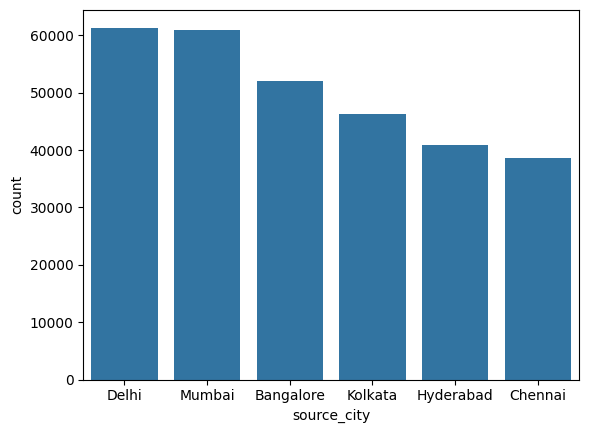

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64


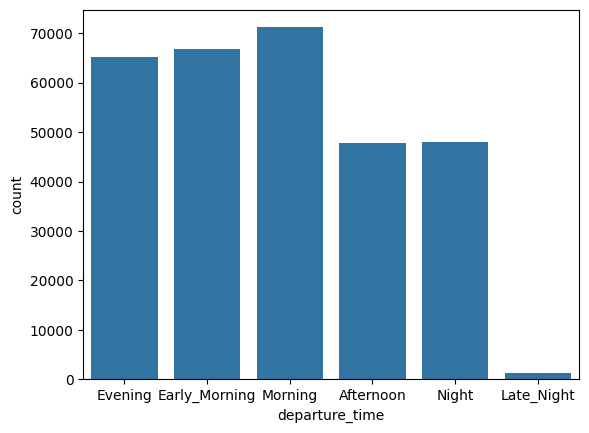

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64


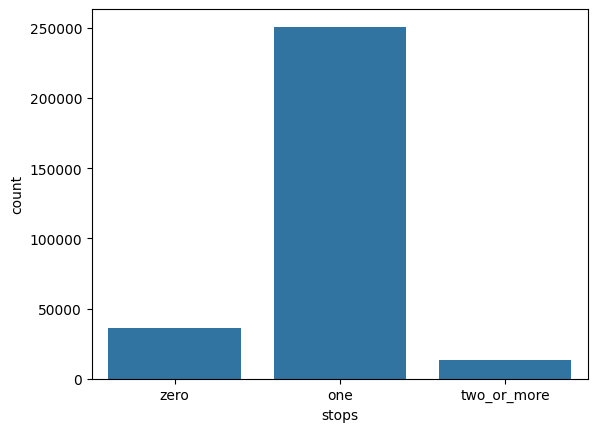

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64


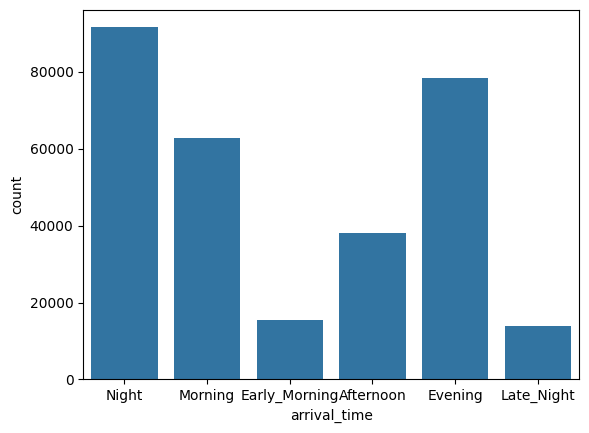

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64


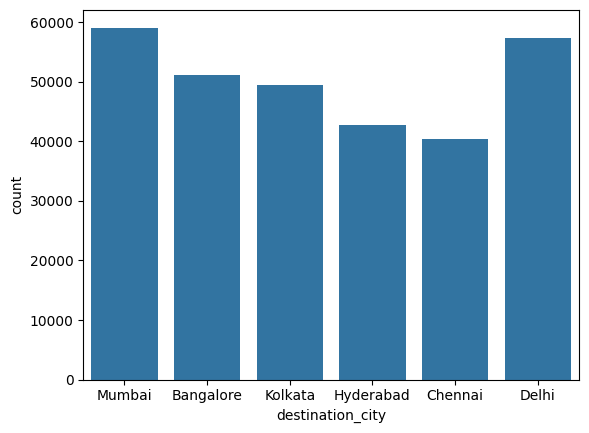

In [20]:
for col in discrete_vars:
    print(df[col].value_counts())
    sns.countplot(data=df, x=col)
    plt.show()

# continuous :

count    300153.000000
mean         12.221021
std           7.191997
min           0.830000
25%           6.830000
50%          11.250000
75%          16.170000
max          49.830000
Name: duration, dtype: float64


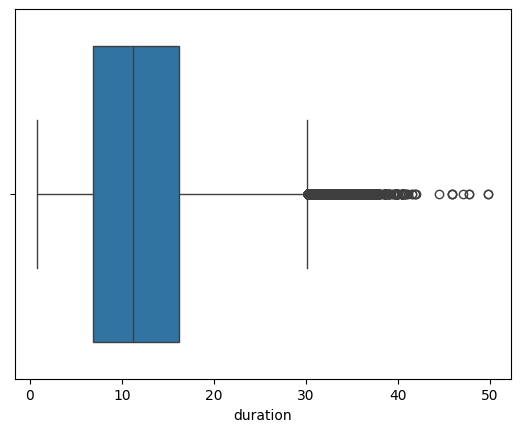

count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64


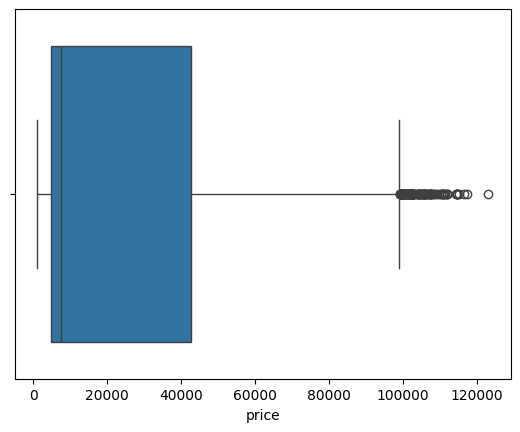

In [19]:
for col in continuous_vars:
    print(df[col].describe())
    sns.boxplot(data=df, x=col)
    plt.show()